# PID Tuning — Interactive Demo

Tune a PID controller against an FOPDT process with live visualization.

**Requirements:** `pip install matplotlib ipywidgets pandas numpy`

In [28]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

from pypid import PID, FOPDTSimulator, Mode

## Simulation Engine

In [29]:
def simulate(Kc, Ti, Td, K_proc=2.0, tau_proc=60.0, theta_proc=10.0,
             sp=50.0, pv0=50.0, t_final=600.0, dt=1.0,
             sp_step_time=60.0, sp_step_size=10.0):
    """Run PID + FOPDT simulation. Returns a DataFrame."""
    pid = PID(Kc=Kc, Ti=Ti, Td=Td, setpoint=sp,
              output_limits=(0, 100), sample_time=None, time_base='minutes')
    sim = FOPDTSimulator(K=K_proc, tau=tau_proc, theta=theta_proc, y0=pv0)

    # Initialize at steady state
    ss_output = pv0 / K_proc if K_proc != 0 else 50.0
    pid.mode = Mode.MANUAL
    pid.output = ss_output
    pid(pv0, dt=dt)
    pid.mode = Mode.AUTO

    data = []
    pv = pv0
    n_steps = int(t_final / dt)

    for i in range(n_steps):
        t = i * dt
        if t >= sp_step_time:
            pid.setpoint = sp + sp_step_size

        output = pid(pv, dt=dt)
        pv = sim.update(output, dt=dt)
        p, integ, d = pid.components
        data.append({
            'time': t, 'pv': pv, 'sp': pid.setpoint,
            'output': output, 'P': Kc*p, 'I': Kc*integ, 'D': Kc*d,
            'error': pid.setpoint - pv,
        })

    return pd.DataFrame(data)

## Plotting Function

In [30]:
def plot_response(df, title='PID Step Response'):
    """3-panel plot: PV/SP, Output, PID components.
    Bottom x-axis: seconds (with tick marks). Top x-axis: minutes."""
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(title, fontsize=12)

    # PV and SP
    ax1.plot(df['time'], df['pv'], 'b-', linewidth=1.5, label='PV')
    ax1.plot(df['time'], df['sp'], 'r--', linewidth=1.5, label='SP')
    ax1.set_ylabel('EU')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Process Variable')

    # Add minutes axis on top of first subplot
    ax1_min = ax1.twiny()
    ax1_min.set_xlim(ax1.get_xlim()[0]/60, ax1.get_xlim()[1]/60)
    ax1_min.set_xlabel('Time (min)')

    # Output
    ax2.plot(df['time'], df['output'], 'g-', linewidth=1.5)
    ax2.set_ylabel('Output (%)')
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Controller Output')

    # PID Components
    ax3.plot(df['time'], df['P'], label='P', color='orange')
    ax3.plot(df['time'], df['I'], label='I', color='purple')
    ax3.plot(df['time'], df['D'], label='D', color='brown')
    ax3.set_ylabel('Contribution')
    ax3.set_xlabel('Time (sec)')
    ax3.legend(loc='upper right')
    ax3.grid(True, alpha=0.3)
    ax3.set_title('PID Components')

    plt.tight_layout()
    plt.show()

## Open-Loop Step Response (Manual Mode)

Before tuning, characterize the process. Put the controller in **Manual**,
make a step change in output, and observe the PV response.

From this you can identify:
- **K** (process gain) = ΔPV / ΔOutput
- **τ** (time constant) = time to reach 63.2% of final value
- **θ** (dead time) = time before PV starts moving

In [27]:
@interact(
    step_size=FloatSlider(value=10.0, min=1.0, max=30.0, step=1.0, description='Step (%)'),
    K_proc=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.1, description='K (gain)'),
    tau_proc=FloatSlider(value=60.0, min=10.0, max=200.0, step=5.0, description='τ (sec)'),
    theta_proc=FloatSlider(value=10.0, min=0.0, max=60.0, step=1.0, description='θ (sec)'),
)
def open_loop_step(step_size, K_proc, tau_proc, theta_proc):
    """Manual mode step test — no PID control."""
    sim = FOPDTSimulator(K=K_proc, tau=tau_proc, theta=theta_proc, y0=50.0)
    
    t_final = 600.0
    dt = 1.0
    step_time = 60.0
    base_output = 25.0
    
    times, pvs, outputs = [], [], []
    pv = 50.0
    
    for i in range(int(t_final / dt)):
        t = i * dt
        # Step change in manual output
        out = base_output + step_size if t >= step_time else base_output
        pv = sim.update(out, dt=dt)
        times.append(t)
        pvs.append(pv)
        outputs.append(out)
    
    # Calculate observed process parameters
    pv_initial = pvs[int(step_time / dt) - 1]
    pv_final = pvs[-1]
    delta_pv = pv_final - pv_initial
    K_obs = delta_pv / step_size
    target_63 = pv_initial + 0.632 * delta_pv
    
    # Key time points
    t_dead = step_time + theta_proc      # when PV starts moving
    t_tau = step_time + theta_proc + tau_proc  # one time constant after dead time
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    fig.suptitle(f'Open-Loop Step Response | K={K_obs:.2f}, τ={tau_proc:.0f}s, θ={theta_proc:.0f}s', fontsize=12)
    
    # PV plot
    ax1.plot(times, pvs, 'b-', linewidth=1.5, label='PV')
    
    # Horizontal reference lines
    ax1.axhline(y=pv_initial, color='gray', linestyle='-', alpha=0.3, linewidth=0.8)
    ax1.axhline(y=pv_final, color='gray', linestyle=':', alpha=0.5, label=f'Final = {pv_final:.1f}')
    ax1.axhline(y=target_63, color='orange', linestyle='--', alpha=0.7, label=f'63.2% = {target_63:.1f}')
    
    # Vertical markers for dead time and tau
    ax1.axvline(x=step_time, color='green', linestyle='-', alpha=0.5, linewidth=1.5, label=f'Step @ {step_time:.0f}s')
    ax1.axvline(x=t_dead, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label=f'θ ends @ {t_dead:.0f}s')
    ax1.axvline(x=t_tau, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, label=f'τ @ {t_tau:.0f}s')
    
    # Mark the 63.2% intersection point
    ax1.plot(t_tau, target_63, 'o', color='orange', markersize=10, zorder=5)
    
    # Annotate dead time span
    ax1.annotate('', xy=(t_dead, pv_initial - 1), xytext=(step_time, pv_initial - 1),
                 arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
    ax1.text((step_time + t_dead)/2, pv_initial - 2.5, f'θ={theta_proc:.0f}s',
             ha='center', color='red', fontsize=9)
    
    # Annotate tau span
    ax1.annotate('', xy=(t_tau, pv_initial - 5), xytext=(t_dead, pv_initial - 5),
                 arrowprops=dict(arrowstyle='<->', color='orange', lw=1.5))
    ax1.text((t_dead + t_tau)/2, pv_initial - 6.5, f'τ={tau_proc:.0f}s',
             ha='center', color='orange', fontsize=9)
    
    ax1.set_ylabel('PV (EU)')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Process Variable')
    
    # Minutes axis on top
    ax1_min = ax1.twiny()
    ax1_min.set_xlim(ax1.get_xlim()[0]/60, ax1.get_xlim()[1]/60)
    ax1_min.set_xlabel('Time (min)')
    
    # Output plot
    ax2.plot(times, outputs, 'g-', linewidth=1.5)
    ax2.axvline(x=step_time, color='green', linestyle='-', alpha=0.5, linewidth=1.5)
    ax2.set_ylabel('Manual Output (%)')
    ax2.set_xlabel('Time (sec)')
    ax2.grid(True, alpha=0.3)
    ax2.set_title('Controller Output (Manual Step)')
    
    plt.tight_layout()
    plt.show()
    
    print(f'  ΔOutput = {step_size:.1f}%')
    print(f'  ΔPV     = {delta_pv:.2f} EU')
    print(f'  K       = {K_obs:.2f} (EU/%)')
    print(f'  τ       = {tau_proc:.0f} s')
    print(f'  θ       = {theta_proc:.0f} s')

interactive(children=(FloatSlider(value=10.0, description='Step (%)', max=30.0, min=1.0, step=1.0), FloatSlide…

## 1. Interactive Tuning with Sliders

Adjust Kc, Ti, Td and see the response update live.

In [31]:
@interact(
    Kc=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Kc (gain)'),
    Ti=FloatSlider(value=2.0, min=0.1, max=20.0, step=0.1, description='Ti (min)'),
    Td=FloatSlider(value=0.0, min=0.0, max=1.0, step=0.02, description='Td (min)'),
)
def tune_pid(Kc, Ti, Td):
    df = simulate(Kc=Kc, Ti=Ti, Td=Td)
    plot_response(df, title=f'Kc={Kc:.1f}, Ti={Ti:.1f} min, Td={Td:.2f} min')

interactive(children=(FloatSlider(value=1.0, description='Kc (gain)', max=5.0, min=0.1), FloatSlider(value=2.0…

## 2. Effect of Gain (Kc) — P-Only Control

Shows offset that exists without integral action.

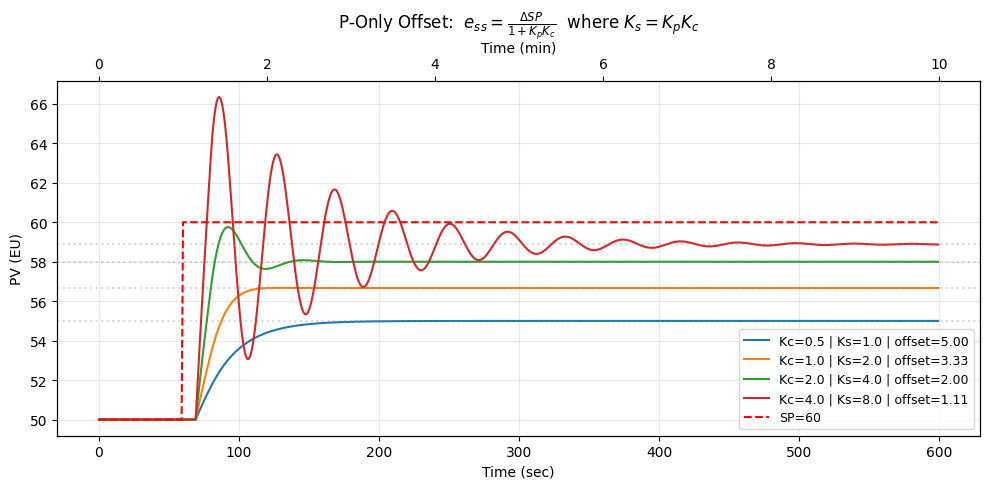

Steady-State Offset Formula:  e_ss = ΔSP / (1 + Kp·Kc)
  Process gain Kp = 2.0
  Step size ΔSP = 10.0

  Kc=0.5  →  Ks=1.0  →  e_ss = 10.0/2.0 = 5.00 EU
  Kc=1.0  →  Ks=2.0  →  e_ss = 10.0/3.0 = 3.33 EU
  Kc=2.0  →  Ks=4.0  →  e_ss = 10.0/5.0 = 2.00 EU
  Kc=4.0  →  Ks=8.0  →  e_ss = 10.0/9.0 = 1.11 EU


In [32]:
K_proc = 2.0  # process gain used in simulate()
sp_step = 10.0  # setpoint step size

plt.figure(figsize=(10, 5))
for Kc in [0.5, 1.0, 2.0, 4.0]:
    df = simulate(Kc=Kc, Ti=None, Td=None)
    # Predicted steady-state offset: e_ss = ΔSP / (1 + Kp*Kc)
    Ks = K_proc * Kc
    e_ss = sp_step / (1 + Ks)
    pv_ss = (50.0 + sp_step) - e_ss  # SP - offset
    plt.plot(df['time'], df['pv'], label=f'Kc={Kc} | Ks={Ks:.1f} | offset={e_ss:.2f}')
    # Mark predicted steady state with a dotted line
    plt.axhline(y=pv_ss, color='gray', linestyle=':', alpha=0.3)

plt.plot(df['time'], df['sp'], 'r--', label='SP=60')
plt.title('P-Only Offset:  $e_{ss} = \\frac{\\Delta SP}{1 + K_p K_c}$  where $K_s = K_p K_c$')
plt.xlabel('Time (sec)')
plt.ylabel('PV (EU)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
ax = plt.gca()
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()[0]/60, ax.get_xlim()[1]/60)
ax2.set_xlabel('Time (min)')
plt.tight_layout()
plt.show()

print('Steady-State Offset Formula:  e_ss = ΔSP / (1 + Kp·Kc)')
print(f'  Ks = Kc · Kp')
print(f'  Process gain Kp = {K_proc}')
print(f'  Step size ΔSP = {sp_step:.1f}')
print()
for Kc in [0.5, 1.0, 2.0, 4.0]:
    Ks = K_proc * Kc
    e_ss = sp_step / (1 + Ks)
    print(f'  Kc={Kc:.1f} · Kp={K_proc:.1f} → Ks={Ks:.1f}  →  e_ss = {sp_step:.1f} / (1 + {Ks:.1f}) = {e_ss:.2f} EU')

## 3. Adding Integral Action (PI Control)

Integral eliminates offset. Smaller Ti = faster reset = more aggressive.

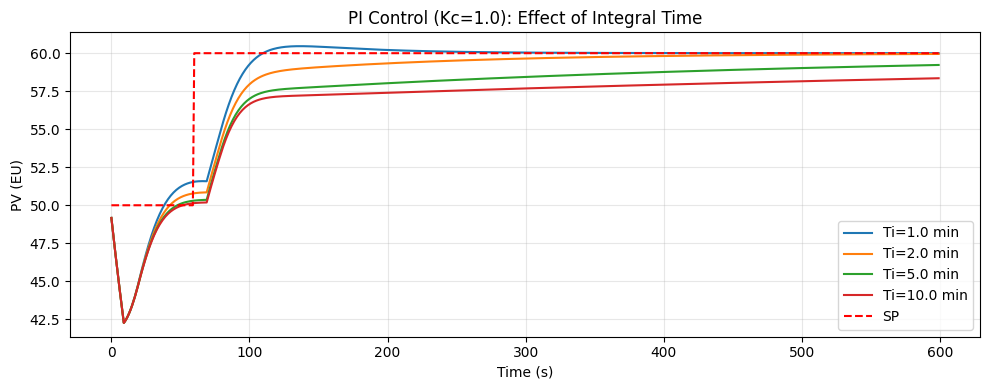

In [12]:
plt.figure(figsize=(10, 4))
for Ti in [1.0, 2.0, 5.0, 10.0]:
    df = simulate(Kc=1.0, Ti=Ti, Td=None)
    plt.plot(df['time'], df['pv'], label=f'Ti={Ti} min')

plt.plot(df['time'], df['sp'], 'r--', label='SP')
plt.title('PI Control (Kc=1.0): Effect of Integral Time')
plt.xlabel('Time (sec)')
plt.ylabel('PV (EU)')
plt.legend()
plt.grid(True, alpha=0.3)
ax = plt.gca()
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()[0]/60, ax.get_xlim()[1]/60)
ax2.set_xlabel('Time (min)')
plt.tight_layout()
plt.show()

## 4. Adding Derivative Action (PID Control)

Derivative anticipates change, reduces overshoot on slow processes.

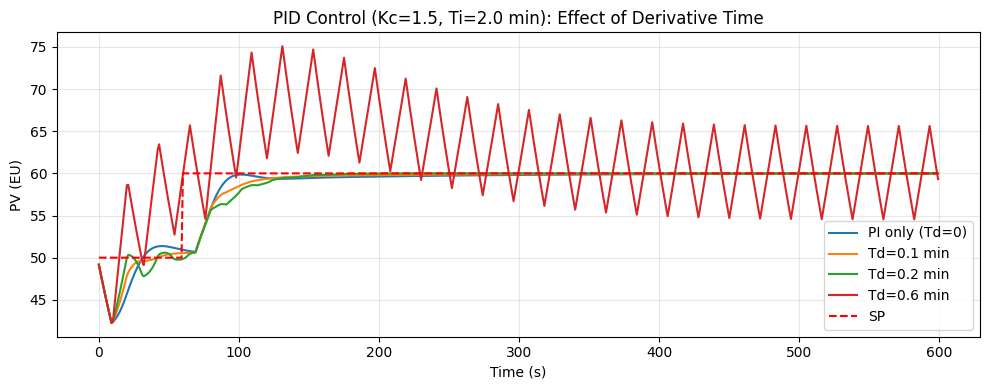

In [14]:
plt.figure(figsize=(10, 4))
for Td in [0.0, 0.1, 0.2, 0.6]:
    label = f'Td={Td} min' if Td > 0 else 'PI only (Td=0)'
    df = simulate(Kc=1.5, Ti=2.0, Td=Td)
    plt.plot(df['time'], df['pv'], label=label)

plt.plot(df['time'], df['sp'], 'r--', label='SP')
plt.title('PID Control (Kc=1.5, Ti=2.0 min): Effect of Derivative Time')
plt.xlabel('Time (sec)')
plt.ylabel('PV (EU)')
plt.legend()
plt.grid(True, alpha=0.3)
ax = plt.gca()
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()[0]/60, ax.get_xlim()[1]/60)
ax2.set_xlabel('Time (min)')
plt.tight_layout()
plt.show()

## 5. Process Dead Time — What Makes Tuning Hard?

Same tuning, different dead times.

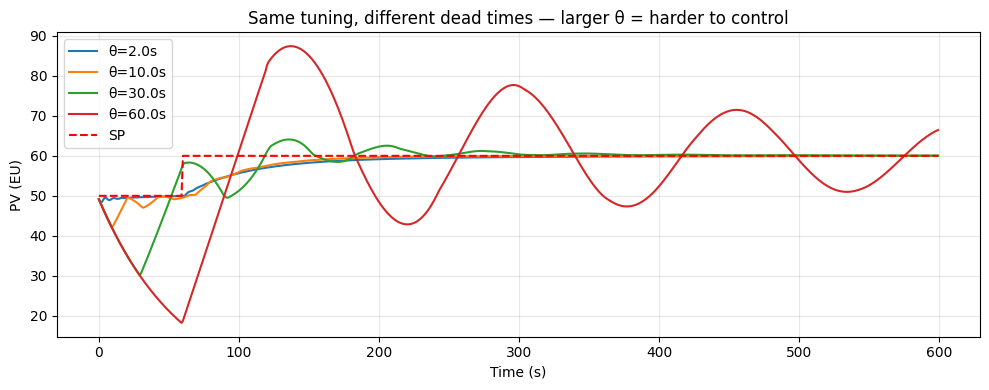

In [15]:
plt.figure(figsize=(10, 4))
for theta in [2.0, 10.0, 30.0, 60.0]:
    df = simulate(Kc=1.0, Ti=2.0, Td=0.3, theta_proc=theta)
    plt.plot(df['time'], df['pv'], label=f'θ={theta}s')

plt.plot(df['time'], df['sp'], 'r--', label='SP')
plt.title('Same tuning, different dead times — larger θ = harder to control')
plt.xlabel('Time (sec)')
plt.ylabel('PV (EU)')
plt.legend()
plt.grid(True, alpha=0.3)
ax = plt.gca()
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim()[0]/60, ax.get_xlim()[1]/60)
ax2.set_xlabel('Time (min)')
plt.tight_layout()
plt.show()

## 6. Full Interactive: Controller + Process Sliders

In [16]:
@interact(
    Kc=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Kc'),
    Ti=FloatSlider(value=2.0, min=0.1, max=20.0, step=0.1, description='Ti (min)'),
    Td=FloatSlider(value=0.0, min=0.0, max=1.0, step=0.02, description='Td (min)'),
    K_proc=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.1, description='K (gain)'),
    tau_proc=FloatSlider(value=60.0, min=10.0, max=200.0, step=5.0, description='τ (sec)'),
    theta_proc=FloatSlider(value=10.0, min=0.0, max=60.0, step=1.0, description='θ (sec)'),
)
def full_tuning(Kc, Ti, Td, K_proc, tau_proc, theta_proc):
    df = simulate(Kc=Kc, Ti=Ti, Td=Td,
                  K_proc=K_proc, tau_proc=tau_proc, theta_proc=theta_proc)
    
    # Performance metrics
    sp_region = df[df['time'] >= 60.0]
    overshoot = (sp_region['pv'].max() - sp_region['sp'].iloc[0]) / 10.0 * 100
    iae = np.trapz(np.abs(sp_region['error']), sp_region['time'])
    
    title = f'Kc={Kc:.1f}, Ti={Ti:.1f}min, Td={Td:.1f}min | OS={overshoot:.0f}% | IAE={iae:.0f}'
    plot_response(df, title=title)

interactive(children=(FloatSlider(value=1.0, description='Kc', max=5.0, min=0.1), FloatSlider(value=2.0, descr…

## 7. Lambda Tuning Rule of Thumb

| Rule | Kc | Ti | Td |
|------|----|----|----|
| Start conservative | 0.5/K | 2×τ (in min) | 0 |
| Lambda (non-aggressive) | τ/(K×λ) | τ (in min) | 0 |

Where λ = desired closed-loop time constant, typically 3×θ.

In [ ]:
# Process parameters
K, tau, theta = 2.0, 60.0, 10.0

# Lambda tuning: lambda = 3 * theta
lam = 3 * theta
Kc_lambda = tau / (K * lam)
Ti_lambda = tau / 60.0  # convert tau (seconds) to minutes

print(f'Process: K={K}, τ={tau}s, θ={theta}s')
print(f'Lambda tuning (λ={lam}s): Kc={Kc_lambda:.2f}, Ti={Ti_lambda:.2f} min')

df = simulate(Kc=Kc_lambda, Ti=Ti_lambda, Td=None,
              K_proc=K, tau_proc=tau, theta_proc=theta)
plot_response(df, title=f'Lambda Tuning: Kc={Kc_lambda:.2f}, Ti={Ti_lambda:.2f} min')